# 22 · DLM clássico em painel: desastres e inadimplência
Isabella Viana Bambirra · Estatística/UFSCar · 06/10/2026.

Referência atual de DLM. Capítulo de metodologia orienta o desenho; dados atuais definem aplicação. Versões 16–21 continuam históricas nas branches documentadas, sem mesclar alterações experimentais. Granger não é reestimado e SARIMAX não é executado.

A pergunta é se mudanças logarítmicas nos registros estão associadas à mudança logarítmica da inadimplência no mesmo mês e nos seis meses seguintes, depois de controlar UF e mês-ano. O caráter é **exploratório**, com validade condicionada à estacionariedade, exogeneidade e estabilidade não comprovadas.

In [1]:
from pathlib import Path
import sys, json
import numpy as np, pandas as pd
from threadpoolctl import threadpool_limits
ROOT=Path.cwd()
if ROOT.name=='notebooks': ROOT=ROOT.parent
assert (ROOT/'src/dlm_painel_log.py').exists(), 'Execute a partir da raiz ou de notebooks'
sys.path.insert(0,str(ROOT/'src'))
import dlm_painel_log as m
print((ROOT/'docs/dlm_painel_log_historico.json').read_text())
print('K fixo:',m.K,'; não há seleção por p, AIC/BIC ou AR')

[
  {
    "branch": "main",
    "sha": "027ee8aa245494765d99bff2511b6f60b30ddf41",
    "agentes": [],
    "notebooks_dlm": []
  },
  {
    "branch": "analise/dlm",
    "sha": "3c94482628b86d1789ee98f8d35f6820835a7219",
    "agentes": [],
    "notebooks_dlm": [
      "notebooks/16_modelos_defasagens_distribuidas.ipynb"
    ]
  },
  {
    "branch": "analise/dlm-revisao-metodologica",
    "sha": "c64589abc0f886a4e55e73b32328f8b0206376aa",
    "agentes": [],
    "notebooks_dlm": [
      "notebooks/16_modelos_defasagens_distribuidas.ipynb",
      "notebooks/17_revisao_metodologica_dlm.ipynb"
    ]
  },
  {
    "branch": "analise/dlm-validacao-final",
    "sha": "87bee9689528b9d273c660ed2aff19c4739d8c54",
    "agentes": [],
    "notebooks_dlm": [
      "notebooks/16_modelos_defasagens_distribuidas.ipynb",
      "notebooks/17_revisao_metodologica_dlm.ipynb",
      "notebooks/18_validacao_final_dlm.ipynb"
    ]
  },
  {
    "branch": "analise/dlm-classico-1a10",
    "sha": "18bc6ef34f02e90810b

## 1. Decisões e teoria efetivamente aplicada
A transformação ocorre antes da diferença: $y_{it}=\log(I_{it})-\log(I_{i,t-1})$, $x_{it}=\log(1+D_{it})-\log(1+D_{i,t-1})$. Não é log da diferença.

$$y_{it}=\alpha_i+\lambda_t+\sum_{k=0}^{6}\beta_k x_{i,t-k}+\varepsilon_{it}.$$

São 27 UFs em todas aplicações, sem ponderação. Efeitos temporais completos são uma dummy para cada mês-ano, não apenas sazonalidade. K=6 é uma janela substantiva de curto prazo, fixa antes dos resultados; associações além dela não são avaliadas. Sete coeficientes livres, sem defasagens de y. A tabela de decisões detalha razões e consequências.

In [2]:
print((ROOT/'docs/dlm_painel_log_protocolo.md').read_text())

# Referência atual: DLM clássico em painel, diferenças logarítmicas

Protocolo definido em 06/10/2026 antes da estimação. O capítulo `c3_metodologias_tg.tex` orienta o DLM finito; a base atual define períodos e unidades. Granger preservado e SARIMAX não executado.

## Decisões prévias

| decisão | por que | implementação | consequência para interpretação |
|---|---|---|---|
| Painel não ponderado de 27 UFs | mesma estrutura em ambos recortes | UF + mês-ano completos, MQO/FWL | coeficiente comum; UFs sem registros permanecem |
| y=Δlog(I); x=Δlog(1+D) | escolha substantiva da autora, comparação coerente | log natural antes da diferença, dentro da UF e do recorte | unidades logarítmicas, não pontos percentuais |
| D=registros administrativos | preservar medida solicitada | linha original do CSV, identificada pelo hash da fonte + número de linha; contar por UF e mês de Data_Evento | não eventos físicos únicos, intensidade ou área atingida |
| Total climático central | classificação sem so

## 2. Conferência de crédito e registros
Exigimos chave única, calendário completo, dados de crédito positivos e razão TI=100CI/CA. Ausência de crédito interrompe a execução. D conta linhas administrativas; protocolo e identificador físico da linha são auditados. Não se deduplica pela significância.

Total climático: selecionar diretamente COBRADE 12/13/14, sem somar grupos/tipologias sobrepostos. Geológicos, biológicos e tecnológicos ficam fora do central. Rótulos Atlas preservados nas aplicações complementares.

In [3]:
d,labels=m.audit()
print(pd.read_csv(m.OUT/'auditoria.csv').to_string(index=False))
print(pd.read_csv(m.OUT/'reconciliacao_atlas.csv').to_string(index=False))
print(pd.read_csv(m.OUT/'taxonomia.csv').to_string(index=False))

   N  UFs  meses  registros  climaticos  repeticoes_chave  protocolos_repetidos  protocolos_ausentes  datas_invalidas  max_diferenca_TI                                                 identificador data_agregacao                                                                        zeros
3888   27    144      40339       37643               101                     0                    0                0      1.776357e-15 sha256 fonte + linha original (cabeçalho=1); não deduplicar A    Data_Evento Ausência de linha na fonte conciliada, não ausência de observação de crédito
                              coluna  total_atlas  total_painel  max_diferenca
                     total_desastres        40339         40339              0
                 grupo_climatologico        19518         19518              0
                   grupo_hidrologico        15409         15409              0
                 grupo_meteorologico         3716          3716              0
                        g

**Interpretação da auditoria:** 3.888 UF-mês, 27×144; 40.339 registros, dos quais 37.643 em COBRADE 12/13/14. As 101 repetições de chave municipal-data-código permanecem em A. Protocolos são distintos nesta fonte, mas não identificam tempestades físicas únicas. Zero significa ausência de linha na fonte reconciliada, não ausência de desastre no mundo real.

Chuvas Intensas inclui código 13310 (onda de calor); Onda de Frio inclui 13120 (frentes frias/zonas de convergência); 14140 é baixa umidade. Não atribuir esses rótulos a fenômenos físicos homogêneos nem às mudanças climáticas antropogênicas.

## 3. Estacionariedade nas séries estaduais transformadas
ADF com intercepto e AIC dentro de limite máximo previamente definido; KPSS com intercepto e banda automática. As UFs são testadas separadamente, sem concatenar estados.

ADF: $\Delta z_t=c+\gamma z_{t-1}+\sum_j\phi_j\Delta z_{t-j}+u_t$; $H_0:\gamma=0$, $H_1:\gamma<0$.

KPSS: $z_t=c+r_t+u_t$, $r_t=r_{t-1}+\eta_t$; $H_0:\operatorname{Var}(\eta_t)=0$, $H_1:\operatorname{Var}(\eta_t)>0$.

Ambos p≥0,05 são inconclusivos. KPSS não rejeitar não comprova estacionariedade; p=0,10 é limite superior da tabela. Com tendência, a hipótese seria estacionariedade em torno da tendência, não do intercepto. Séries constantes ficam registradas como indisponíveis.

In [4]:
st=m.stationarity(d,labels)
print(st.groupby(['periodo','exposicao','classificacao']).size().to_string())
print(st[(st.exposicao=='inadimplencia') & (st.classificacao=='desfavorável')][['periodo','uf','ADF_p','KPSS_p','ADF_lag','KPSS_lag']].to_string(index=False))

periodo  exposicao                             classificacao
Pré      grupo_climatologico                   divergente        2
                                               favorável        20
                                               indisponível      5
         grupo_hidrologico                     divergente        1
                                               favorável        25
                                               indisponível      1
         grupo_meteorologico                   divergente        1
                                               favorável        15
                                               inconclusivo      1
                                               indisponível     10
         grupo_outros                          divergente        7
                                               favorável        13
                                               indisponível      7
         inadimplencia                         desfavorável      2
 

/workspace/scratch/cda0e0d514cf/tcc/src/dlm_painel_log.py:85: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  ad=adfuller(s,maxlag=ml,regression='c',autolag='AIC');base.update(ADF_estatistica=ad[0],ADF_p=ad[1],ADF_lag=ad[2],ADF_n=ad[3],ADF_IC=ad[5],**{'ADF_crit_'+k:v for k,v in ad[4].items()})
/workspace/scratch/cda0e0d514cf/tcc/src/dlm_painel_log.py:85: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior a

**Interpretação:** em Δlog(I), pré: 6 favoráveis, 19 inconclusivas e 2 desfavoráveis (RO, SC); total: 18 favoráveis, 8 inconclusivas e 1 desfavorável (RO). Não alterar a transformação para obter p favorável. A evidência desfavorável impede apresentar o painel completo como validado e limita as inferências a associações exploratórias condicionais. FE/covariância robusta não corrigem raiz unitária.

Os resultados nacionais informados (ADF≈0,343 no pré e ≈0,021 no total; KPSS≥0,10) não são comprovação estadual. CIPS histórico de ΔI e cobertura é uma evidência em outras unidades/transformações, não um teste novo destas séries.

In [5]:
print('CIPS histórico, transformação diferente:')
print(pd.read_csv(ROOT/'docs/historico_dlm/cips_delta_I.csv').to_string(index=False))
print(pd.read_csv(ROOT/'docs/historico_dlm/cips_cobertura.csv').head(12).to_string(index=False))

CIPS histórico, transformação diferente:
periodo              serie deterministico  lags      CIPS        p  N   T
  Total taxa_inadimplencia          drift     1 -2.254054 0.028125 27 144
  Total taxa_inadimplencia          drift     2 -2.291687 0.017723 27 144
  Total taxa_inadimplencia          trend     1 -1.882181 0.100000 27 144
  Total taxa_inadimplencia          trend     2 -1.783215 0.100000 27 144
  Total              delta          drift     1 -6.172200 0.010000 27 143
  Total              delta          drift     2 -5.645215 0.010000 27 143
    Pré taxa_inadimplencia          drift     1 -2.148554 0.063257 27  85
    Pré taxa_inadimplencia          drift     2 -2.048473 0.100000 27  85
    Pré taxa_inadimplencia          trend     1 -2.354220 0.100000 27  85
    Pré taxa_inadimplencia          trend     2 -2.275085 0.100000 27  85
    Pré              delta          drift     1 -5.700526 0.010000 27  84
    Pré              delta          drift     2 -4.987469 0.010000 27  

## 4. Construção de lags, amostras e identificação
Diferenças e lags dentro de UF e recorte, sem meses anteriores inventados. Primeira equação ago/2013: perder 1 mês de diferença + 6 para lags em cada UF. Pré e total são sobrepostos.

MQO por FWL: remover médias de UF e de mês-ano e devolver média geral no painel balanceado. Identificação exige posto completo e variação após ambos FE. Não recorrer a pseudoinversa para declarar identificação.

Inferência CR1, 27 clusters, t26 e Wald F(r,26). DK6 usa Bartlett em scores mensais, correção finita e t(T−1)/F(r,T−1), como comparação única diante da dependência transversal. Suporte insuficiente não recebe teste.

In [6]:
with threadpool_limits(limits=1):
    r=m.estimate(d,labels,st)
print(pd.read_csv(m.OUT/'amostras_suporte.csv').to_string(index=False))
print(pd.read_csv(m.OUT/'modelos.csv').to_string(index=False))

Pré total_climatico estimado
Pré grupo_climatologico estimado
Pré grupo_hidrologico estimado
Pré grupo_meteorologico estimado
Pré grupo_outros estimado
Pré tipo_alagamentos estimado
Pré tipo_chuvas_intensas estimado
Pré tipo_doencas_infecciosas estimado
Pré tipo_enxurradas estimado
Pré tipo_erosao estimado
Pré tipo_estiagem_e_seca estimado
Pré tipo_granizo estimado
Pré tipo_incendio_florestal estimado
Pré tipo_inundacoes estimado
Pré tipo_movimento_de_massa estimado
Pré tipo_onda_de_frio estimado
Pré tipo_outros estimado
Pré tipo_tornado estimado
Pré tipo_vendavais_e_ciclones estimado
Total total_climatico estimado
Total grupo_climatologico estimado
Total grupo_hidrologico estimado
Total grupo_meteorologico estimado
Total grupo_outros estimado
Total tipo_alagamentos estimado
Total tipo_chuvas_intensas estimado
Total tipo_doencas_infecciosas estimado
Total tipo_enxurradas estimado
Total tipo_erosao estimado
Total tipo_estiagem_e_seca estimado
Total tipo_granizo estimado
Total tipo_incen

**Interpretação da amostra:** pré 2.106 observações (78×27), total 3.699 (137×27), com todas UFs. Cada janela perde 189 células no início. Categorias sem suporte não se tornam modelos estaduais ou outra metodologia.

## 5. Validação e diagnósticos
Conferir coeficientes e CR1 com MQO de dummies explícitas nas aplicações centrais; conferir DK contra implementação independente de statsmodels. Variância da soma usa $\mathbf{1}'V\mathbf{1}$, incluindo covariâncias. Matrizes de covariância completas são exportadas.

Ljung–Box por UF é diagnóstico residual descritivo; não substitui cluster. Correlações residuais entre UFs justificam DK. CD ingênuo após efeitos fixos temporais não fornece teste calibrado, pois a centralização temporal induz correlação. Levene é descritivo por depender de independência. Influência é medida por alavancagem e scores das UFs, sem excluir estados para obter significância.

In [7]:
print(pd.read_csv(m.OUT/'validacao.csv').to_string(index=False))
print(pd.read_csv(m.OUT/'diagnosticos.csv').to_string(index=False))
print(pd.read_csv(m.OUT/'autocorrelacao_uf.csv').groupby(['periodo','lag']).p.apply(lambda s:(s<.05).sum()).to_string())
print(pd.read_csv(m.OUT/'influencia_uf.csv').query("exposicao=='total_climatico'").sort_values('share_variancia_acumulado',ascending=False).head(8).to_string(index=False))

periodo       exposicao   nivel                                                  rotulo  K  DK_statsmodels_max_diff  coef_FWL_dummies_max_diff  cov_CR1_dummies_max_diff  var_soma  soma_todas_covariancias  passou
    Pré total_climatico Central Total climático / hidrometeorológico (COBRADE 12/13/14)  6             1.429368e-21               6.071532e-17              7.305659e-21  0.000018                 0.000018    True
  Total total_climatico Central Total climático / hidrometeorológico (COBRADE 12/13/14)  6             2.011703e-21               4.000706e-17              3.282253e-21  0.000008                 0.000008    True
periodo                            exposicao     nivel                                                  rotulo  K  CD_naive  CD_p_naive                                                             CD_ressalva  rho_media  rho_abs_media  rho_max   rho_min    Levene  Levene_p_descritivo                                 hetero_ressalva  max_VIF  max_cor_lags  max_alav

**Limitações:** há dependência residual entre estados e variação de dispersão. A correlação média absoluta residual central é aproximadamente 0,169 no pré e 0,173 no total. DK não transforma o desenho em causal nem elimina mudanças na dinâmica. Condicionamento e correlação dos lags centrais permitem o DLM irrestrito; Almon não foi necessário.

Correções do capítulo: exogeneidade estrita deve condicionar todo o histórico de x e FE; origem natural não basta. Normalidade/homocedasticidade não são condições universais da consistência de MQO robusto. Para Almon, se futuramente necessário, $Z^{(0)}=\sum_{k=0}^Kx_{t-k}$ e $Z^{(j)}=\sum_{k=0}^Kk^jx_{t-k}$; $\beta_k=\sum_{j=0}^qa_jk^j$, $V_\beta=BV_aB'$. Potências brutas não garantem menor correlação. Não se usa Almon nesta execução.

## 6. Resultados e multiplicidade
Endpoints separados: β0, soma0:6, soma1:6, conjunto0:6 e conjunto1:6. BH por período × nível × covariância × endpoint; categorias indisponíveis mantêm a família com p=1 apenas para ajuste conservador. Seus testes continuam ausentes. Perfis individuais são descritivos com IC95% pontuais, não simultâneos.

In [8]:
print(r[r.exposicao=='total_climatico'][['periodo','covariancia','endpoint','estimate','low','high','p','q_BH']].to_string(index=False))
print('Todas rejeições BH por categoria:')
print(r[r.q_BH<.05][['periodo','rotulo','covariancia','endpoint','estimate','p','q_BH']].to_string(index=False))

periodo covariancia   endpoint  estimate       low     high        p     q_BH
    Pré         CR1      beta0  0.000048 -0.000836 0.000933 0.911405 0.911405
    Pré         CR1     soma0K  0.002709 -0.006075 0.011493 0.531682 0.531682
    Pré         CR1     soma1K  0.002661 -0.005716 0.011038 0.519585 0.519585
    Pré         CR1 conjunto0K  0.504062       NaN      NaN 0.822892 0.822892
    Pré         CR1 conjunto1K  0.587578       NaN      NaN 0.737089 0.737089
    Pré         DK6      beta0  0.000048 -0.000804 0.000900 0.910356 0.910356
    Pré         DK6     soma0K  0.002709 -0.004475 0.009893 0.455025 0.455025
    Pré         DK6     soma1K  0.002661 -0.003971 0.009292 0.426803 0.426803
    Pré         DK6 conjunto0K  0.774765       NaN      NaN 0.610246 0.610246
    Pré         DK6 conjunto1K  0.863665       NaN      NaN 0.525542 0.525542
  Total         CR1      beta0  0.000623 -0.000010 0.001256 0.053432 0.053432
  Total         CR1     soma0K  0.004372 -0.001265 0.010009 0.12

**Interpretação central:** soma0:6 pré=0,002709, IC CR1 [−0,006075;0,011493], p=0,532; total=0,004372, IC [−0,001265;0,010009], p=0,123. DK6: p≈0,455/0,056. Não há rejeição central a 5%; isso não prova ausência de associação. P diferentes nas janelas sobrepostas não demonstram mudança temporal.

Movimento de Massa no total tem soma rejeitada após BH/CR1, mas não após BH/DK6. Trata-se de categoria geológica complementar fora do total climático central. Resultados conjuntos podem existir sem soma diferente de zero, por compensação entre lags. Categorias concentradas e diagnósticos desfavoráveis exigem ressalvas mesmo quando p/q são pequenos.

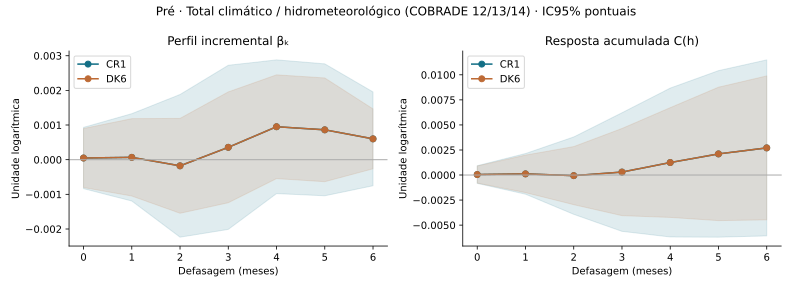

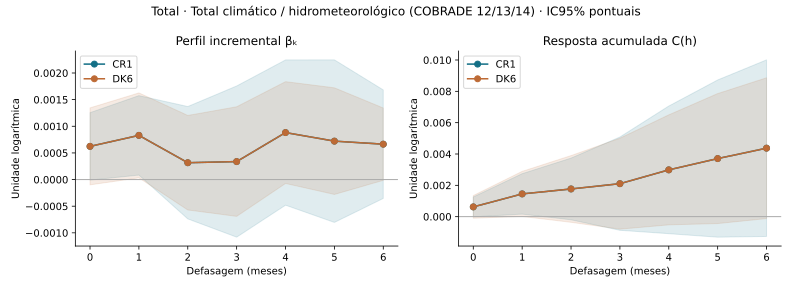

In [9]:
m.figures()
for per in m.PERIODS:
    p=m.FIG/(m.slug(per)+'_total_climatico.svg')
    emit('image/svg+xml',p.read_text())

## 7. Cenários na escala correta
βk relaciona mudança logarítmica de registros à mudança logarítmica de I no lag k, condicionada a lags e FE. Não é ponto percentual ou elasticidade simples em D.

Contraste 0→1 registro: δx=log2. Aumento persistente no nível D gera um pulso em Δlog1p(D). Pulso de um mês em D gera +log2 e depois −log2. Convoluir ambas mudanças com β, acumular em log(I) e converter $100[\exp(\text{resposta acumulada})-1]$. Os cenários são contrafactuais algébricos condicionais, não previsão causal de um desastre físico.

In [10]:
sc=pd.read_csv(m.OUT/'cenarios.csv')
print(sc[(sc.exposicao=='total_climatico') & (sc.covariancia=='CR1')].to_string(index=False))
m.manifest()
print(json.loads((m.OUT/'manifest.json').read_text())['versoes'])

periodo       exposicao   nivel                                                  rotulo  K covariancia                            cenario  h  delta_x_inicial  resposta_delta_log_I  resposta_log_I_acumulada  variacao_relativa_I_pct   low_pct  high_pct
    Pré total_climatico Central Total climático / hidrometeorológico (COBRADE 12/13/14)  6         CR1    aumento persistente D: 0 para 1  0         0.693147              0.000034                  0.000034                 0.003350 -0.057927  0.064665
    Pré total_climatico Central Total climático / hidrometeorológico (COBRADE 12/13/14)  6         CR1    aumento persistente D: 0 para 1  1         0.693147              0.000047                  0.000080                 0.008031 -0.132492  0.148751
    Pré total_climatico Central Total climático / hidrometeorológico (COBRADE 12/13/14)  6         CR1    aumento persistente D: 0 para 1  2         0.693147             -0.000123                 -0.000043                -0.004252 -0.271628  0.263

**Conclusão:** o desenho solicitado é estimável para exposições com suporte, mas permanece exploratório. O total climático não apresenta evidência robusta de associação acumulada no horizonte de seis meses nesta execução. A análise não estabelece causalidade, não atribui registros a mudanças climáticas antropogênicas e não testa ausência de efeito. Transformações iguais mantêm a definição da variável; não resolvem diagnósticos, dependência ou dinâmica instável.

Reprodução: colocar as duas entradas nos caminhos indicados no manifesto; instalar requirements-dlm-painel-log.lock.txt; executar este notebook na raiz/notebooks ou `python src/executar_notebook_painel_log.py notebooks/22_dlm_painel_diferencas_logaritmicas.ipynb`. O executor registra saídas reais em namespace Python compartilhado, sem simular execução. HTML: `python src/relatorio_dlm_painel_log.py`.